# Membrane protein localization states from Human Protein Atlas image embeddings

This notebook explores whether plasma membrane-associated proteins form multiple reproducible localization states in Human Protein Atlas single-cell image embedding space.

The main goal is not simply to identify plasma membrane proteins, but to test whether this broad category can be decomposed into biologically meaningful subtypes related to trafficking, cortical organization, adhesion, polarity, and signaling.

## Biological motivation

Plasma membrane proteins are usually grouped into one broad localization class.  
However, the plasma membrane contains multiple functional microdomains involved in signaling, adhesion, trafficking, polarity, and mechanics.

This notebook tests whether plasma membrane proteins separate into reproducible latent states in image embedding space.

## Notebook contents

1. Load Human Protein Atlas annotation and embedding tables  
2. Construct a plasma membrane target label  
3. Merge localization annotations with image embedding features  
4. Run a baseline supervised classification check  
5. Restrict the analysis to plasma membrane-associated proteins  
6. Standardize features and perform PCA  
7. Cluster proteins in latent embedding space  
8. Evaluate clustering quality across multiple values of k  
9. Assess robustness with bootstrap clustering stability  
10. Interpret clusters using localization annotations and marker genes  
11. Check for possible technical biases (cell line / antibody)  
12. Assign biological names to the final clusters  
13. Summarize conclusions and next steps

## Analysis Plan

The analysis follows three stages.

**Stage 1. Data preparation**  
Load the Human Protein Atlas tables, harmonize column names, and define a plasma membrane-associated target label from localization annotations.

**Stage 2. Exploratory modeling**  
First, test whether image embeddings can separate plasma membrane-associated proteins from the rest. This serves as a sanity check, but not as the final scientific objective.

**Stage 3. Unsupervised discovery**  
Focus only on plasma membrane-associated proteins and test whether they split into reproducible latent states using PCA, KMeans clustering, stability analysis, and biological interpretation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score

from sklearn.metrics import (silhouette_score,calinski_harabasz_score,davies_bouldin_score)
import seaborn as sns




## 1. Data loading

I start by importing the required libraries and loading two Human Protein Atlas tables:

- a localization annotation table
- a single-cell image embedding feature table

These datasets will later be merged through gene identifiers.

In [2]:
BASE_DIR = Path("/Users/ulialarina/Documents/поступление в пхд/пет_проект")

loc_file = BASE_DIR / "subcellular_location.tsv"
feat_file = BASE_DIR / "subcell_image_umap_features.tsv"

print("subcellular_location.tsv exists:", loc_file.exists())
print("subcell_image_umap_features.tsv exists:", feat_file.exists())

subcellular_location.tsv exists: True
subcell_image_umap_features.tsv exists: True



Human Protein Atlas provides large-scale microscopy-derived protein localization data across multiple cell lines.

This makes it possible to study membrane organization computationally at scale rather than protein-by-protein.

In [3]:
loc = pd.read_csv(loc_file, sep="\t")
feat = pd.read_csv(feat_file, sep="\t")

In [4]:
print("loc shape:", loc.shape)
print("feat shape:", feat.shape)

loc shape: (13603, 14)
feat shape: (81007, 1034)


In [5]:
loc.head(3)

,Gene,Gene name,Reliability,Main location,Additional location,Extracellular location,Enhanced,Supported,Approved,Uncertain,Single-cell variation intensity,Single-cell variation spatial,Cell cycle dependency,GO id
0,ENSG00000000003,TSPAN6,Approved,Cell Junctions;Cytosol,Nucleoli fibrillar center,NaN,NaN,NaN,Cell Junctions;Cytosol;Nucleoli fibrillar center,NaN,Cytosol,NaN,NaN,Cell Junctions (GO:0030054);Cytosol (GO:000582...
1,ENSG00000000457,SCYL3,Supported,Cytosol;Golgi apparatus,NaN,NaN,NaN,Cytosol;Golgi apparatus,NaN,NaN,NaN,NaN,NaN,Cytosol (GO:0005829);Golgi apparatus (GO:0005794)
2,ENSG00000000460,C1orf112,Supported,Nucleoplasm,Nucleoli,NaN,NaN,Nucleoli;Nucleoplasm,NaN,NaN,NaN,NaN,NaN,Nucleoli (GO:0005730);Nucleoplasm (GO:0005654)


In [6]:
[c for c in feat.columns if "Gene" in c or "gene" in c]

['genes']

## 2. Constructing a plasma membrane target label

To identify plasma membrane-associated proteins, I construct a binary target variable (`target_pm`).

A protein is marked as plasma membrane-associated if the phrase **"Plasma membrane"** appears in at least one of the following annotation fields:

- `Main location`
- `Additional location`
- `Supported`
- `Approved`

This broad definition is intentionally inclusive, because the later unsupervised analysis is designed to resolve heterogeneity within this category.

In [7]:
loc["target_pm"] = (
    loc["Main location"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Additional location"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Supported"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Approved"].fillna("").str.contains("Plasma membrane", case=False)
).astype(int)

loc["target_pm"].value_counts()

target_pm
0    11340
1     2263
Name: count, dtype: int64

In [8]:
loc["target_pm"].head()

0    0
1    0
2    0
3    1
4    0
Name: target_pm, dtype: int64

## Limitation of the binary labeling

The plasma membrane target is annotation-derived.  
Therefore, binary classification is used only as a sanity check, not as the main scientific result.

In [9]:
feat["genes"].head()

0     CD4
1     CD4
2    FUT4
3    FUT4
4    CD99
Name: genes, dtype: str

In [10]:
loc["Gene"].head()

0    ENSG00000000003
1    ENSG00000000457
2    ENSG00000000460
3    ENSG00000000938
4    ENSG00000000971
Name: Gene, dtype: str

In [11]:
loc["Gene name"].head()

0      TSPAN6
1       SCYL3
2    C1orf112
3         FGR
4         CFH
Name: Gene name, dtype: str

## 3. Column harmonization and dataset merge

Before merging the tables, I standardize column names to lowercase snake_case format. This reduces the risk of merge errors and makes the downstream code more consistent.

The two datasets are then merged by gene identifier:
- `feat["genes"]`
- `loc["gene_name"]`

In [12]:
loc.columns = (
    loc.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

feat.columns = (
    feat.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(loc.columns.tolist())
print(feat.columns.tolist()[:20])

['gene', 'gene_name', 'reliability', 'main_location', 'additional_location', 'extracellular_location', 'enhanced', 'supported', 'approved', 'uncertain', 'single-cell_variation_intensity', 'single-cell_variation_spatial', 'cell_cycle_dependency', 'go_id', 'target_pm']
['file_prefix', 'cell_line', 'antibody', 'genes', 'locations', 'umap2d_x', 'umap2d_y', 'umap3d_x', 'umap3d_y', 'umap3d_z', 'image_feature_1', 'image_feature_2', 'image_feature_3', 'image_feature_4', 'image_feature_5', 'image_feature_6', 'image_feature_7', 'image_feature_8', 'image_feature_9', 'image_feature_10']


In [13]:
df = feat.merge(
    loc[["gene_name", "target_pm"]],
    left_on="genes",
    right_on="gene_name",
    how="inner"
)

print(df.shape)
df.head()

(78429, 1036)


,file_prefix,cell_line,antibody,genes,locations,umap2d_x,umap2d_y,umap3d_x,umap3d_y,umap3d_z,...,image_feature_1017,image_feature_1018,image_feature_1019,image_feature_1020,image_feature_1021,image_feature_1022,image_feature_1023,image_feature_1024,gene_name,target_pm
0,https://images.proteinatlas.org/11/203_H3_1,U-251MG,CAB000011,CD4,Plasma membrane,2.373975,6.717113,2.794099,4.460743,5.437658,...,0.327689,-0.046523,-0.078425,0.065497,0.015063,0.031387,-0.029221,-0.140267,CD4,1
1,https://images.proteinatlas.org/11/203_H3_2,U-251MG,CAB000011,CD4,Plasma membrane,2.345751,6.946063,2.746736,4.604968,5.388471,...,0.292907,-0.015529,-0.078425,0.088387,0.011603,0.031387,-0.029221,-0.140267,CD4,1
2,https://images.proteinatlas.org/14/204_F1_1,A-431,CAB000014,FUT4,Vesicles,1.157088,7.179945,2.070618,3.923071,4.766505,...,0.177152,0.378285,0.496419,0.111779,0.011603,0.031387,-0.029221,-0.118652,FUT4,0
3,https://images.proteinatlas.org/14/204_F1_2,A-431,CAB000014,FUT4,Vesicles,1.234408,7.090076,2.192031,3.856368,4.848568,...,0.316824,0.258880,0.153130,0.073486,0.011603,0.031387,-0.029221,-0.086059,FUT4,0
4,https://images.proteinatlas.org/20/203_G10_1,U-251MG,CAB000020,CD99,Golgi apparatus,4.239029,-0.217924,3.477636,0.916252,5.313524,...,0.308078,-0.046523,-0.078425,-0.110081,0.011603,0.098623,-0.029221,0.272358,CD99,0


In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Количество числовых колонок:", len(numeric_cols))
print(numeric_cols[:30])

Количество числовых колонок: 1030
['umap2d_x', 'umap2d_y', 'umap3d_x', 'umap3d_y', 'umap3d_z', 'image_feature_1', 'image_feature_2', 'image_feature_3', 'image_feature_4', 'image_feature_5', 'image_feature_6', 'image_feature_7', 'image_feature_8', 'image_feature_9', 'image_feature_10', 'image_feature_11', 'image_feature_12', 'image_feature_13', 'image_feature_14', 'image_feature_15', 'image_feature_16', 'image_feature_17', 'image_feature_18', 'image_feature_19', 'image_feature_20', 'image_feature_21', 'image_feature_22', 'image_feature_23', 'image_feature_24', 'image_feature_25']


In [15]:
feature_cols = [c for c in numeric_cols if c != "target_pm"]

X = df[feature_cols]
y = df["target_pm"]

print(X.shape)
print(y.shape)

(78429, 1029)
(78429,)


### Split the merged dataset into train and test subsets.
### This first split is row-based and serves as a baseline estimate.

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(62743, 1029) (15686, 1029)


In [17]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    loss_function="Logloss",
    verbose=50,
    random_state=42
)

model.fit(X_train, y_train)

0:	total: 136ms	remaining: 40.5s
50:	total: 3.27s	remaining: 15.9s
100:	total: 6.12s	remaining: 12.1s
150:	total: 8.96s	remaining: 8.84s
200:	total: 11.8s	remaining: 5.79s
250:	total: 14.5s	remaining: 2.82s
299:	total: 17.2s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=50)

In [18]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC AUC: 0.8972429381312199
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     13076
           1       0.78      0.55      0.64      2610

    accuracy                           0.90     15686
   macro avg       0.85      0.76      0.79     15686
weighted avg       0.89      0.90      0.89     15686



### Gene-level split control

Because multiple rows may correspond to the same gene, I also perform a gene-aware split using `GroupShuffleSplit`. This reduces the risk of overestimating performance due to leakage across repeated observations of the same gene.

## 4. Baseline supervised classification check

As an initial sanity check, I test whether the numerical image embeddings can distinguish plasma membrane-associated proteins from all others.

This is not the main scientific objective of the project. Since the target itself is derived from localization annotations, good classification performance would mainly show that the embedding space captures biologically relevant localization information.

I therefore use this step only as a preliminary validation before moving to the main unsupervised question.

In [19]:
groups = df["genes"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [20]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    verbose=50
)

model.fit(X_train, y_train)

0:	total: 70ms	remaining: 20.9s
50:	total: 3.32s	remaining: 16.2s
100:	total: 6.52s	remaining: 12.8s
150:	total: 9.45s	remaining: 9.33s
200:	total: 12.3s	remaining: 6.07s
250:	total: 15.2s	remaining: 2.98s
299:	total: 18.1s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, verbose=50)

In [21]:
proba = model.predict_proba(X_test)[:,1]
print("Gene-split AUC:", roc_auc_score(y_test, proba))

Gene-split AUC: 0.8910320528710738


In [22]:
pm_df = df[df["target_pm"] == 1].copy()

print(pm_df.shape)
pm_df.head()

(13049, 1036)


,file_prefix,cell_line,antibody,genes,locations,umap2d_x,umap2d_y,umap3d_x,umap3d_y,umap3d_z,...,image_feature_1017,image_feature_1018,image_feature_1019,image_feature_1020,image_feature_1021,image_feature_1022,image_feature_1023,image_feature_1024,gene_name,target_pm
0,https://images.proteinatlas.org/11/203_H3_1,U-251MG,CAB000011,CD4,Plasma membrane,2.373975,6.717113,2.794099,4.460743,5.437658,...,0.327689,-0.046523,-0.078425,0.065497,0.015063,0.031387,-0.029221,-0.140267,CD4,1
1,https://images.proteinatlas.org/11/203_H3_2,U-251MG,CAB000011,CD4,Plasma membrane,2.345751,6.946063,2.746736,4.604968,5.388471,...,0.292907,-0.015529,-0.078425,0.088387,0.011603,0.031387,-0.029221,-0.140267,CD4,1
10,https://images.proteinatlas.org/35/674_H5_5,A-431,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.868301,6.337133,2.997809,4.785375,6.077948,...,0.023639,-0.035206,-0.078425,0.082895,0.011603,0.031387,-0.029221,-0.140267,EGFR,1
11,https://images.proteinatlas.org/35/674_H5_6,A-431,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.847926,6.399388,2.942690,4.839087,6.051414,...,0.047139,0.212975,-0.078425,0.106316,0.011603,0.031387,-0.029221,-0.140267,EGFR,1
12,https://images.proteinatlas.org/35/665_H5_1,U-251MG,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.336322,7.110271,2.587930,5.064015,5.530016,...,0.023639,-0.046523,-0.078425,0.137057,0.087311,0.031387,0.133958,-0.140267,EGFR,1


In [23]:
numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm]

print(X_pm.shape)

(13049, 1029)


In [24]:
pm_df = df[df["target_pm"] == 1].copy()

print(pm_df.shape)

(13049, 1036)


In [25]:
numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm].copy()

print(X_pm.shape)

(13049, 1029)


In [26]:
scaler = StandardScaler()
X_pm_scaled = scaler.fit_transform(X_pm)

X_pm_scaled.shape

(13049, 1029)

## Main hypothesis

If plasma membrane proteins are heterogeneous, then image embeddings should reveal multiple subgroups rather than one continuous cloud.

In [27]:
pca = PCA(n_components=30, random_state=42)
X_pm_pca = pca.fit_transform(X_pm_scaled)

print(X_pm_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

(13049, 30)
Explained variance ratio sum: 0.7665709076461777


## 5. Restricting the analysis to plasma membrane-associated proteins

The main question of this project is whether plasma membrane proteins form multiple latent organizational states rather than one homogeneous class.

To test this, I subset the merged dataset to proteins with `target_pm == 1` and then perform unsupervised analysis only within this plasma membrane-enriched subset.

In [28]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

pm_df["cluster"] = kmeans.fit_predict(X_pm_pca)

pm_df["cluster"].value_counts().sort_index()

cluster
0    1337
1    3894
2    4876
3    2345
4     597
Name: count, dtype: int64

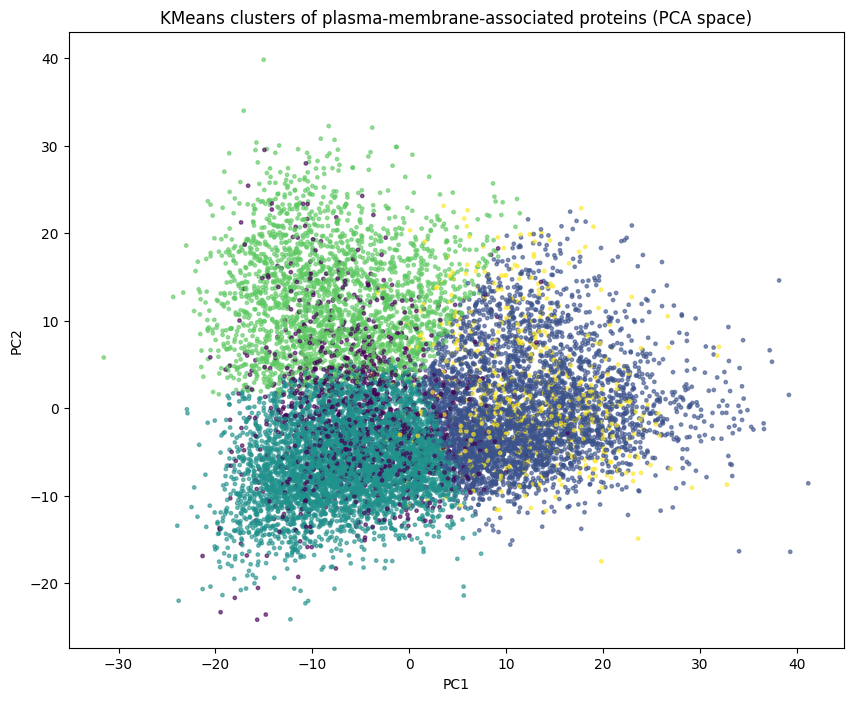

In [29]:
plt.figure(figsize=(10, 8))
plt.scatter(
    X_pm_pca[:, 0],
    X_pm_pca[:, 1],
    c=pm_df["cluster"],
    s=6,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters of plasma-membrane-associated proteins (PCA space)")
plt.show()

The PCA projection suggests partial separation of several regions, indicating that membrane proteins may occupy multiple organizational states.

## 7. Initial cluster interpretation with localization annotations

To interpret the latent clusters, I rebuild the merged table with additional annotation columns, including:

- `main_location`
- `additional_location`
- `supported`
- `approved`
- `reliability`

These metadata allow me to examine whether the clusters correspond to distinct localization patterns rather than arbitrary partitions in feature space.

In [30]:
df = feat.merge(
    loc[[
        "gene_name",
        "main_location",
        "additional_location",
        "supported",
        "approved",
        "reliability",
        "target_pm"
    ]],
    left_on="genes",
    right_on="gene_name",
    how="inner"
)

print(df.shape)

(78429, 1041)


## 6. Feature standardization, PCA, and initial clustering

The embedding features are first standardized because clustering is sensitive to scale.

I then apply PCA to reduce dimensionality while preserving the dominant structure of the embedding space. This helps denoise the data and makes clustering more stable.

An initial KMeans solution is used as a first exploratory view of structure in plasma membrane-associated proteins.

In [31]:
pm_df = df[df["target_pm"] == 1].copy()

numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm].copy()


scaler = StandardScaler()
X_pm_scaled = scaler.fit_transform(X_pm)

pca = PCA(n_components=30, random_state=42)
X_pm_pca = pca.fit_transform(X_pm_scaled)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
pm_df["cluster"] = kmeans.fit_predict(X_pm_pca)

pm_df["cluster"].value_counts().sort_index()

cluster
0    1337
1    3894
2    4876
3    2345
4     597
Name: count, dtype: int64



Cluster number was not chosen arbitrarily.  
Several metrics were compared to identify a solution balancing compactness, separation, and interpretability.

In [32]:
cluster_main = pd.crosstab(pm_df["cluster"], pm_df["main_location"], normalize="index")
cluster_main.round(3)

main_location,Acrosome;Mid piece;Plasma membrane,Acrosome;Plasma membrane,Actin filaments,Actin filaments;Cell Junctions;Plasma membrane,Actin filaments;Connecting piece;Mid piece;Plasma membrane,Actin filaments;Cytoplasmic bodies,Actin filaments;Cytosol,Actin filaments;Cytosol;Plasma membrane,Actin filaments;Focal adhesion sites;Plasma membrane,Actin filaments;Microtubules,...,Nucleoplasm;Plasma membrane;Vesicles,Nucleoplasm;Primary cilium,Nucleoplasm;Vesicles,Peroxisomes;Vesicles,Plasma membrane,Plasma membrane;Primary cilium,Plasma membrane;Principal piece,Plasma membrane;Vesicles,Primary cilium;Primary cilium tip;Vesicles,Vesicles
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.004,0.000,0.052,0.003,0.004,0.001,0.016,0.02,0.009,0.008,...,0.000,0.000,0.000,0.000,0.162,0.000,0.000,0.025,0.001,0.023
1,0.001,0.001,0.005,0.000,0.000,0.000,0.000,0.00,0.001,0.000,...,0.002,0.001,0.000,0.001,0.508,0.003,0.001,0.031,0.000,0.012
2,0.000,0.000,0.002,0.000,0.000,0.000,0.003,0.00,0.000,0.000,...,0.000,0.000,0.001,0.002,0.266,0.002,0.000,0.036,0.000,0.031
3,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.00,0.000,0.000,...,0.007,0.003,0.010,0.000,0.136,0.000,0.000,0.032,0.000,0.014
4,0.000,0.002,0.007,0.000,0.000,0.003,0.000,0.00,0.005,0.000,...,0.002,0.000,0.005,0.000,0.350,0.003,0.000,0.022,0.000,0.015


In [33]:
cluster_add = pd.crosstab(pm_df["cluster"], pm_df["additional_location"], normalize="index")
cluster_add.round(3)

additional_location,Acrosome;Actin filaments;Centrosome;Cytokinetic bridge;End piece;Equatorial segment;Mid piece;Nucleoplasm;Principal piece,Acrosome;Annulus;Mid piece;Nucleoplasm,Acrosome;Basal body;Cytosol;Plasma membrane;Primary cilium tip;Principal piece,Acrosome;Basal body;Equatorial segment,Acrosome;Cell Junctions,Acrosome;Cytosol;Mid piece;Midbody;Principal piece,Acrosome;Cytosol;Nuclear bodies;Nucleoplasm;Vesicles,Acrosome;Cytosol;Principal piece,Acrosome;Endoplasmic reticulum;Equatorial segment;Nucleoplasm;Plasma membrane,Acrosome;Plasma membrane;Vesicles,...,Primary cilium tip;Vesicles,Primary cilium;Primary cilium tip,Primary cilium;Primary cilium tip;Primary cilium transition zone;Vesicles,Primary cilium;Primary cilium tip;Principal piece,Primary cilium;Primary cilium transition zone,Primary cilium;Primary cilium transition zone;Vesicles,Primary cilium;Vesicles,Rods & Rings,Rods & Rings;Vesicles,Vesicles
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.006,0.000,0.000,0.000,0.000,0.002,0.000,0.006,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.003,0.000,0.004
1,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.001,0.001,0.000,0.002,0.001,0.003,0.000,0.001,0.060
2,0.000,0.001,0.000,0.004,0.001,0.000,0.000,0.000,0.001,0.001,...,0.002,0.001,0.000,0.002,0.000,0.001,0.002,0.001,0.001,0.046
3,0.000,0.001,0.002,0.000,0.000,0.000,0.003,0.000,0.001,0.000,...,0.000,0.000,0.001,0.001,0.000,0.000,0.004,0.000,0.001,0.018
4,0.000,0.000,0.000,0.000,0.005,0.000,0.000,0.000,0.000,0.000,...,0.000,0.005,0.000,0.000,0.003,0.000,0.000,0.000,0.000,0.046


In [34]:
for cl in sorted(pm_df["cluster"].unique()):
    print("=" * 60)
    print("CLUSTER", cl)

    tmp = (
        pm_df[pm_df["cluster"] == cl]["main_location"]
        .value_counts()
        .head(10)
    )

    print(tmp)

CLUSTER 0
main_location
Plasma membrane                    216
Actin filaments;Plasma membrane     72
Actin filaments                     70
Golgi apparatus                     59
Cytosol;Plasma membrane             50
Golgi apparatus;Plasma membrane     43
Mitochondria                        42
Cytosol                             35
Plasma membrane;Vesicles            33
Vesicles                            31
Name: count, dtype: int64
CLUSTER 1
main_location
Plasma membrane                        1979
Cytosol;Plasma membrane                 519
Nucleoplasm;Plasma membrane             151
Cytosol                                 129
Nucleoplasm                             127
Plasma membrane;Vesicles                122
Cell Junctions;Plasma membrane          109
Golgi apparatus;Plasma membrane          68
Cytosol;Nucleoplasm;Plasma membrane      51
Vesicles                                 48
Name: count, dtype: int64
CLUSTER 2
main_location
Cytosol;Plasma membrane                1313
Pl

In [35]:
for cl in sorted(pm_df["cluster"].unique()):
    print("=" * 60)
    print("CLUSTER", cl)

    tmp = (
        pm_df[pm_df["cluster"] == cl]["additional_location"]
        .value_counts()
        .head(10)
    )

    print(tmp)

CLUSTER 0
additional_location
Plasma membrane                    186
Cytosol;Plasma membrane             67
Nucleoplasm;Plasma membrane         48
Actin filaments                     40
Plasma membrane;Vesicles            32
Actin filaments;Plasma membrane     32
Nucleoli;Plasma membrane            28
Golgi apparatus                     22
Cell Junctions;Plasma membrane      21
Actin filaments;Cytosol             18
Name: count, dtype: int64
CLUSTER 1
additional_location
Nucleoplasm                    276
Plasma membrane                244
Cytosol                        193
Vesicles                       134
Cytosol;Plasma membrane         89
Golgi apparatus                 76
Cell Junctions                  41
Nuclear speckles                33
Cytosol;Vesicles                31
Nucleoplasm;Plasma membrane     31
Name: count, dtype: int64
CLUSTER 2
additional_location
Plasma membrane                    659
Cytosol                            281
Nucleoplasm                        190
V

In [36]:
silhouette_score(X_pm_pca, pm_df["cluster"])

0.10605791630792365

## 8. Choosing the number of clusters

An initial clustering is not enough; the number of clusters must be evaluated more systematically.

To do this, I compare several values of `k` using three complementary metrics:

- **Silhouette score**: higher is better  
- **Calinski-Harabasz score**: higher is better  
- **Davies-Bouldin score**: lower is better

The goal is not to optimize a single metric blindly, but to identify a solution that is both quantitatively reasonable and biologically interpretable.

In [37]:
cluster_metrics = []

for k in range(4, 9):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = km.fit_predict(X_pm_pca)

    cluster_metrics.append({
        "k": k,
        "silhouette": silhouette_score(X_pm_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pm_pca, labels),
        "davies_bouldin": davies_bouldin_score(X_pm_pca, labels)
    })

metrics_df = pd.DataFrame(cluster_metrics).sort_values("k")
metrics_df

,k,silhouette,calinski_harabasz,davies_bouldin
0,4,0.098517,1107.965678,2.588780
1,5,0.105441,1023.042740,2.411148
2,6,0.111997,970.307237,2.256098
3,7,0.119639,922.663516,2.055952
4,8,0.088145,881.137373,2.152150


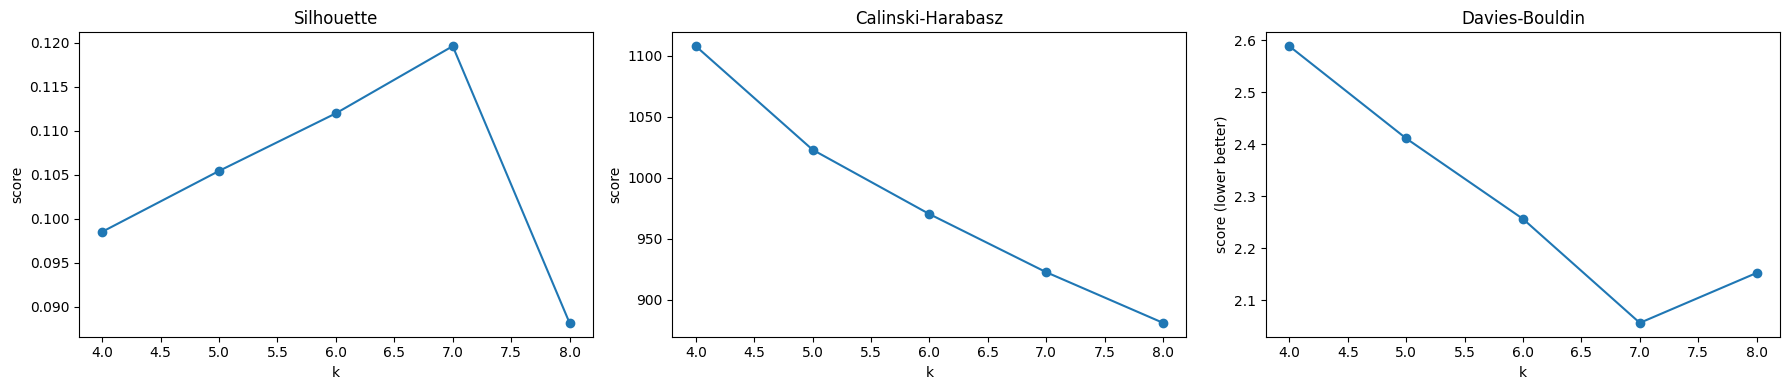

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(metrics_df["k"], metrics_df["silhouette"], marker="o")
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("score")

axes[1].plot(metrics_df["k"], metrics_df["calinski_harabasz"], marker="o")
axes[1].set_title("Calinski-Harabasz")
axes[1].set_xlabel("k")
axes[1].set_ylabel("score")

axes[2].plot(metrics_df["k"], metrics_df["davies_bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("k")
axes[2].set_ylabel("score (lower better)")

plt.tight_layout()
plt.show()

In [39]:
best_k_sil = metrics_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k_sil = int(best_k_sil)
best_k_sil

7

In [40]:
kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=20)
pm_df["cluster"] = kmeans.fit_predict(X_pm_pca)

pm_df["cluster"].value_counts().sort_index()

cluster
0    1338
1    3757
2    2231
3     535
4    4479
5     592
6     117
Name: count, dtype: int64

## 9. Bootstrap cluster stability

To test whether the discovered structure is reproducible rather than a random artifact of sampling, I evaluate clustering stability with a bootstrap-style procedure.

In each iteration:
1. I sample two overlapping subsets of the data
2. I cluster both subsets independently
3. I compare the cluster assignments on the overlapping observations using Adjusted Rand Index (ARI)

Higher ARI values indicate a more reproducible latent structure.

In [41]:

def bootstrap_cluster_stability(X, k=5, n_boot=12, sample_frac=0.8, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    ari_scores = []

    for i in range(n_boot):
        idx1 = rng.choice(n, size=int(n * sample_frac), replace=False)
        idx2 = rng.choice(n, size=int(n * sample_frac), replace=False)

        overlap = np.intersect1d(idx1, idx2)
        if len(overlap) < 100:
            continue

        km1 = KMeans(n_clusters=k, random_state=100 + i, n_init=20)
        km2 = KMeans(n_clusters=k, random_state=200 + i, n_init=20)

        lab1 = km1.fit_predict(X[idx1])
        lab2 = km2.fit_predict(X[idx2])

        idx1_map = {v: j for j, v in enumerate(idx1)}
        idx2_map = {v: j for j, v in enumerate(idx2)}

        overlap_lab1 = np.array([lab1[idx1_map[o]] for o in overlap])
        overlap_lab2 = np.array([lab2[idx2_map[o]] for o in overlap])

        ari = adjusted_rand_score(overlap_lab1, overlap_lab2)
        ari_scores.append(ari)

    return ari_scores

stability_scores = bootstrap_cluster_stability(
    X_pm_pca,
    k=int(pm_df["cluster"].nunique()),
    n_boot=12,
    sample_frac=0.8,
    random_state=42
)

print("ARI scores:", stability_scores)
print("Mean ARI:", np.mean(stability_scores))
print("Std ARI:", np.std(stability_scores))

ARI scores: [0.925077879967574, 0.9581838770918139, 0.9577416515721918, 0.9609415334757552, 0.5469181675347133, 0.9841585858389003, 0.9770519553547572, 0.9833674758944383, 0.5563581651263052, 0.9481618797545311, 0.9653626227391029, 0.9673143055369466]
Mean ARI: 0.8942198416572525
Std ARI: 0.15397799167595144


In [42]:
summary_rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl].copy()

    top_main = sub["main_location"].fillna("NA").value_counts().head(5).index.tolist()
    top_add = sub["additional_location"].fillna("NA").value_counts().head(5).index.tolist()
    top_genes = sub["genes"].value_counts().head(10).index.tolist()
    top_cell_lines = sub["cell_line"].value_counts().head(5).index.tolist()

    summary_rows.append({
        "cluster": cl,
        "n_rows": len(sub),
        "n_genes": sub["genes"].nunique(),
        "top_main_location": "; ".join(map(str, top_main)),
        "top_additional_location": "; ".join(map(str, top_add)),
        "top_cell_lines": "; ".join(map(str, top_cell_lines)),
        "top_genes": "; ".join(map(str, top_genes))
    })

cluster_summary_df = pd.DataFrame(summary_rows).sort_values("cluster")
cluster_summary_df

,cluster,n_rows,n_genes,top_main_location,top_additional_location,top_cell_lines,top_genes
0,0,1338,525,Plasma membrane; Golgi apparatus; Vesicles; Pl...,NA; Plasma membrane; Cytosol;Plasma membrane; ...,U2OS; A-431; U-251MG; SiHa; Rh30,IRAK4; EGFR; CLTA; SIRT2; RRP12; BRAF; FADS2; ...
1,1,3757,1307,Plasma membrane; Cytosol;Plasma membrane; Nucl...,NA; Nucleoplasm; Plasma membrane; Cytosol; Ves...,U2OS; A-431; U-251MG; HeLa; HEL,MSN; EZR; CTNNB1; EGFR; SLC16A1; PALM2AKAP2; C...
2,2,2231,665,Nucleoplasm; Plasma membrane; Nucleoplasm;Plas...,Plasma membrane; NA; Cytosol;Plasma membrane; ...,U2OS; U-251MG; A-431; PC-3; HeLa,ACSS2; CEBPE; POGZ; DLL3; KLHL7; DNAJC9; INTS1...
3,3,535,182,Plasma membrane; Actin filaments;Plasma membra...,NA; Plasma membrane; Actin filaments; Actin fi...,U2OS; A-431; U-251MG; BJ [Human fibroblast]; Rh30,FLNA; LUZP1; SEPTIN2; MYH9; CALD1; PPP1R12A; C...
4,4,4479,1237,Cytosol;Plasma membrane; Plasma membrane; Cyto...,NA; Plasma membrane; Cytosol; Nucleoplasm; Ves...,U2OS; U-251MG; A-431; PC-3; MCF-7,CAST; GPI; HSPB1; GAPVD1; ARHGEF1; FSCN1; CFLA...
5,5,592,268,Plasma membrane; Cell Junctions;Plasma membran...,NA; Nucleoplasm; Plasma membrane; Cell Junctio...,A-431; MCF-7; U2OS; CACO-2; RT-4,AFDN; KIAA1522; TJP3; ARVCF; PAK4; LSR; EPB41;...
6,6,117,49,Focal adhesion sites; Focal adhesion sites;Pla...,NA; Actin filaments;Plasma membrane; Cell Junc...,U2OS; U-251MG; A-431; SiHa; RT-4,ZYX; ENAH; LPP; VASP; LASP1; TES; CUTA; RAPGEF...


In [43]:
gene_cluster_df = (
    pm_df.groupby("genes")["cluster"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"cluster": "gene_major_cluster"})
)

gene_meta_df = (
    pm_df.groupby("genes")
    .agg({
        "main_location": lambda x: x.dropna().astype(str).value_counts().index[0] if len(x.dropna()) > 0 else np.nan,
        "additional_location": lambda x: x.dropna().astype(str).value_counts().index[0] if len(x.dropna()) > 0 else np.nan,
        "cell_line": "nunique",
        "antibody": "nunique"
    })
    .reset_index()
)

gene_df = gene_cluster_df.merge(gene_meta_df, on="genes", how="left")
gene_df.head()

,genes,gene_major_cluster,main_location,additional_location,cell_line,antibody
0,AADAT,1,Plasma membrane,Vesicles,3,1
1,AAK1,4,Plasma membrane,Cytosol;Vesicles,4,2
2,AAMP,0,Microtubules,Cytokinetic bridge;Cytosol;Plasma membrane;Pri...,4,2
3,ABCA1,0,Plasma membrane,Golgi apparatus,3,1
4,ABCA12,0,Plasma membrane;Vesicles,Cytosol;Nucleoli,3,1


These gene lists form one of the main reusable outputs of the project. They can later be used for GO enrichment, literature review, and communication with potential PhD supervisors.

## GO enrichment and membrane-mechanics signatures

To strengthen the biological interpretation of the clusters, I perform two complementary analyses:

1. **GO enrichment analysis** for each cluster  
   This tests whether cluster gene sets are enriched in processes related to focal adhesion, actin cytoskeleton, endocytosis, tight junctions, and receptor signaling.

2. **Targeted membrane-mechanics signature analysis**  
   This tests whether clusters are enriched in manually curated protein groups associated with:
   - cortical membrane organization
   - focal adhesion / motility
   - contractility
   - curvature / tension sensitivity
   - caveolae
   - ezrin/moesin cortical coupling
   - BAR-domain proteins
   - endocytic adaptors
   - integrin pathway

This does not directly measure membrane dynamics, but it can reveal whether some clusters are consistent with distinct membrane mechanical regimes.

In [53]:
# Prepare one clean gene list per cluster

cluster_gene_sets = {
    cl: sorted(
        gene_df.loc[gene_df["gene_major_cluster"] == cl, "genes"]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )
    for cl in sorted(gene_df["gene_major_cluster"].dropna().unique())
}

for cl, genes in cluster_gene_sets.items():
    print(f"Cluster {cl}: {len(genes)} genes")
    print(genes[:15], "\n")

Cluster 0: 211 genes
['AAMP', 'ABCA1', 'ABCA12', 'ABCB6', 'ABCC4', 'ACP4', 'ADCY4', 'ADCY5', 'AGRN', 'AGTPBP1', 'AJM1', 'AKAP5', 'AKTIP', 'AMER1', 'APOBR'] 

Cluster 1: 604 genes
['AADAT', 'ABCC3', 'ABCC6', 'ABCG2', 'ABI1', 'ACKR3', 'ADAM12', 'ADAMTS2', 'ADCY7', 'ADD1', 'ADD3', 'ADGRA2', 'ADH7', 'ADORA1', 'ADPRHL1'] 

Cluster 2: 353 genes
['ABCB11', 'ABCB4', 'ABCC9', 'ABHD3', 'ACOT9', 'ACSS2', 'ACTL10', 'ACTR10', 'ADCY3', 'ADCY8', 'ADD2', 'ADK', 'ADRM1', 'ANKFN1', 'ANKRD42'] 

Cluster 3: 78 genes
['ADAM23', 'APPL1', 'ARHGAP21', 'ARHGAP33', 'ARL13A', 'ATP6V1H', 'AVEN', 'AXL', 'BZW2', 'C11ORF42', 'CALD1', 'CCDC69', 'CD274', 'CDC42EP1', 'CDC42EP3'] 

Cluster 4: 739 genes
['AAK1', 'ABCA7', 'ABCB1', 'ABCC1', 'ACTR6', 'ADA', 'ADAM10', 'ADAM28', 'ADAM33', 'ADAMTS1', 'ADAMTSL4', 'ADAP1', 'ADCK5', 'ADCY9', 'ADGRB2'] 

Cluster 5: 83 genes
['ABCC5', 'ACTN1', 'ADGRL2', 'AFDN', 'AFM', 'AGER', 'ARVCF', 'ATP1A1', 'C2CD2L', 'CACNA1I', 'CADM1', 'CAVIN3', 'CCDC66', 'CD34', 'CD9'] 

Cluster 6: 16 genes
[

In [54]:
pip install gprofiler-official


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [55]:
from gprofiler import GProfiler
import pandas as pd
import numpy as np

gp = GProfiler(return_dataframe=True)

go_results = []

for cl, genes in cluster_gene_sets.items():
    if len(genes) < 5:
        continue

    res = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:BP", "GO:CC"],
        user_threshold=0.05
    )

    if res is None or len(res) == 0:
        continue

    res = res.copy()
    res["cluster"] = cl
    go_results.append(res)

if len(go_results) > 0:
    go_df = pd.concat(go_results, ignore_index=True)
else:
    go_df = pd.DataFrame()

print("GO results shape:", go_df.shape)
go_df.head()

GO results shape: (1206, 15)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:CC,GO:0005886,plasma membrane,5.292294e-42,True,"""The membrane surrounding a cell that separate...",5906,204,150,22155,0.735294,0.025398,query_1,"[GO:0016020, GO:0071944]",0
1,GO:CC,GO:0071944,cell periphery,2.880734e-41,True,"""The broad region around and including the pla...",6263,204,153,22155,0.750000,0.024429,query_1,[GO:0110165],0
2,GO:CC,GO:0016020,membrane,9.055031e-30,True,"""A lipid bilayer along with all the proteins a...",9975,204,173,22155,0.848039,0.017343,query_1,[GO:0110165],0
3,GO:CC,GO:0120025,plasma membrane bounded cell projection,6.973954e-09,True,"""A prolongation or process extending from a ce...",2449,204,57,22155,0.279412,0.023275,query_1,[GO:0042995],0
4,GO:CC,GO:0042995,cell projection,1.414446e-08,True,"""A prolongation or process extending from a ce...",2566,204,58,22155,0.284314,0.022603,query_1,[GO:0110165],0


In [56]:
# Keep only terms related to the biological themes of interest

keywords = [
    "focal adhesion",
    "cell-substrate junction",
    "actin cytoskeleton",
    "actin filament",
    "endocytosis",
    "endocytic",
    "tight junction",
    "cell junction",
    "adherens junction",
    "receptor signaling",
    "transmembrane receptor",
    "signal transduction",
    "cortical actin",
    "membrane raft",
    "caveola",
    "integrin",
    "lamellipodium",
    "cell migration",
    "cytoskeleton organization",
    "contractile",
    "actomyosin"
]

if len(go_df) > 0:
    mask = go_df["name"].str.lower().apply(
        lambda x: any(k in x for k in keywords)
    )
    go_focus_df = go_df.loc[mask].copy()
    go_focus_df = go_focus_df.sort_values(["cluster", "p_value", "source"])
else:
    go_focus_df = pd.DataFrame()

go_focus_df[[
    "cluster", "source", "name", "p_value", "term_size",
    "query_size", "intersection_size", "effective_domain_size"
]].head(50)

,cluster,source,name,p_value,term_size,query_size,intersection_size,effective_domain_size
15,0,GO:BP,cell surface receptor signaling pathway,7.009528e-06,2834,192,57,20972
26,0,GO:BP,signal transduction,1.802802e-04,6063,192,90,20972
28,0,GO:BP,regulation of signal transduction,2.035300e-04,3031,192,56,20972
52,0,GO:BP,positive regulation of signal transduction,4.086145e-03,1569,192,34,20972
81,0,GO:BP,brain-derived neurotrophic factor receptor sig...,2.577712e-02,57,192,6,20972
84,0,GO:CC,membrane raft,2.674056e-02,289,204,11,22155
91,0,GO:BP,endocytosis,4.234550e-02,694,192,19,20972
99,1,GO:CC,cell junction,2.561214e-43,2370,578,186,22155
113,1,GO:BP,signal transduction,2.123493e-22,6063,549,274,20972
115,1,GO:CC,cell-cell junction,6.305764e-22,522,578,63,22155


In [57]:
# Show the most relevant GO terms per cluster

if len(go_focus_df) > 0:
    for cl in sorted(go_focus_df["cluster"].unique()):
        print("=" * 100)
        print(f"CLUSTER {cl}")
        display(
            go_focus_df.loc[go_focus_df["cluster"] == cl, [
                "source", "name", "p_value", "intersection_size", "term_size"
            ]].head(15)
        )
else:
    print("No focused GO terms found with the current keyword filter.")

CLUSTER 0


,source,name,p_value,intersection_size,term_size
15,GO:BP,cell surface receptor signaling pathway,0.000007,57,2834
26,GO:BP,signal transduction,0.000180,90,6063
28,GO:BP,regulation of signal transduction,0.000204,56,3031
52,GO:BP,positive regulation of signal transduction,0.004086,34,1569
81,GO:BP,brain-derived neurotrophic factor receptor sig...,0.025777,6,57
84,GO:CC,membrane raft,0.026741,11,289
91,GO:BP,endocytosis,0.042345,19,694


CLUSTER 1


,source,name,p_value,intersection_size,term_size
99,GO:CC,cell junction,2.561214e-43,186,2370
113,GO:BP,signal transduction,2.123493e-22,274,6063
115,GO:CC,cell-cell junction,6.305764e-22,63,522
118,GO:BP,cell migration,7.449977e-20,111,1532
131,GO:CC,cell-substrate junction,1.283259e-17,52,435
133,GO:CC,focal adhesion,2.529770e-17,51,425
134,GO:BP,actin cytoskeleton organization,5.947621e-17,68,716
137,GO:BP,actin filament-based process,2.668443e-16,72,816
144,GO:CC,membrane raft,1.805223e-15,40,289
155,GO:BP,regulation of signal transduction,5.271767e-14,155,3031


CLUSTER 2


...

,source,name,p_value,intersection_size,term_size
737,GO:BP,signal transduction,5.958329e-27,333,6063
743,GO:CC,cell junction,1.317638e-22,171,2370
746,GO:BP,cell surface receptor signaling pathway,2.455313e-18,183,2834
768,GO:BP,intracellular signal transduction,5.693138e-13,174,2963
769,GO:BP,cell migration,6.039842e-13,111,1532
771,GO:BP,actin filament-based process,1.345373e-12,74,816
774,GO:BP,actin cytoskeleton organization,7.800121e-12,67,716
782,GO:BP,regulation of signal transduction,4.788140e-11,171,3031
784,GO:BP,cytoskeleton organization,1.851291e-10,105,1534
785,GO:BP,endocytosis,2.200386e-10,63,694


CLUSTER 5


,source,name,p_value,intersection_size,term_size
1113,GO:CC,cell-cell junction,1.607756e-21,27,522
1114,GO:CC,cell junction,1.891614e-21,46,2370
1117,GO:BP,cell-cell junction organization,9.276110e-15,17,216
1121,GO:CC,tight junction,3.854450e-11,12,140
1122,GO:CC,adherens junction,6.029681e-11,13,189
1124,GO:CC,bicellular tight junction,6.863006e-10,11,134
1125,GO:BP,cell-cell junction assembly,1.457480e-09,12,157
1126,GO:BP,cell junction organization,5.503189e-09,21,829
1133,GO:BP,cell migration,4.270966e-07,25,1532
1135,GO:BP,cell junction assembly,1.404638e-06,15,509


CLUSTER 6


,source,name,p_value,intersection_size,term_size
1197,GO:CC,focal adhesion,2.569565e-08,8,425
1198,GO:CC,cell-substrate junction,3.089664e-08,8,435
1201,GO:CC,contractile actin filament bundle,4.282204e-05,4,83
1202,GO:CC,actomyosin,5.936287e-05,4,90
1203,GO:CC,actin filament bundle,6.206524e-05,4,91
1204,GO:CC,cell junction,1.116278e-04,10,2370
1205,GO:CC,actin cytoskeleton,3.822490e-03,5,537


In [58]:
import re

theme_map = {
    "focal_adhesion": [
        "focal adhesion", "cell-substrate junction", "integrin"
    ],
    "actin_cytoskeleton": [
        "actin cytoskeleton", "actin filament", "cortical actin", "actomyosin", "contractile"
    ],
    "endocytosis": [
        "endocytosis", "endocytic"
    ],
    "tight_junction": [
        "tight junction", "cell junction", "adherens junction"
    ],
    "receptor_signaling": [
        "receptor signaling", "transmembrane receptor", "signal transduction"
    ],
    "migration_motility": [
        "cell migration", "lamellipodium"
    ],
    "caveola_rafts": [
        "caveola", "membrane raft"
    ]
}

theme_rows = []

if len(go_df) > 0:
    for cl in sorted(go_df["cluster"].unique()):
        sub = go_df[go_df["cluster"] == cl].copy()
        names = sub["name"].fillna("").str.lower()

        row = {"cluster": cl}
        for theme, pats in theme_map.items():
            matched = sub[names.apply(lambda x: any(p in x for p in pats))]
            if len(matched) == 0:
                row[theme] = 0.0
            else:
                # stronger significance -> higher score
                row[theme] = (-np.log10(matched["p_value"].clip(lower=1e-300))).max()
        theme_rows.append(row)

go_theme_df = pd.DataFrame(theme_rows).set_index("cluster")
go_theme_df

,focal_adhesion,actin_cytoskeleton,endocytosis,tight_junction,receptor_signaling,migration_motility,caveola_rafts
cluster,,,,,,,
0,0.000000,0.000000,1.373193,0.000000,5.154311,0.000000,1.572829
1,16.891686,16.225657,6.552137,42.591554,21.672949,19.127845,14.743469
2,0.000000,2.058880,0.000000,5.223655,4.875163,0.000000,0.000000
3,4.211251,30.138238,0.000000,9.315816,0.000000,0.000000,0.000000
4,8.702058,11.871157,9.657501,21.880204,26.224876,12.218974,5.168544
5,2.129053,3.936605,0.000000,20.793780,0.000000,6.369474,0.000000
6,7.590140,4.368333,0.000000,3.952228,0.000000,0.000000,0.000000


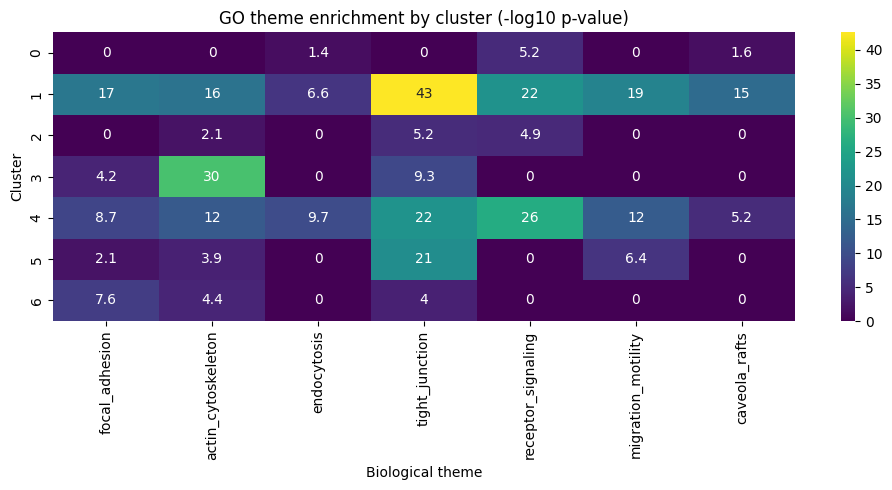

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(go_theme_df, annot=True, cmap="viridis")
plt.title("GO theme enrichment by cluster (-log10 p-value)")
plt.xlabel("Biological theme")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Targeted membrane-mechanics signatures

Because static image embeddings cannot directly measure membrane fluctuations or resonance, I test a weaker but biologically meaningful question:

Do some clusters show enrichment for proteins associated with distinct membrane mechanical regimes?

The curated signatures include:
- cortical membrane coupling
- focal adhesion / migration
- contractility
- curvature / tension sensitivity
- caveolae
- ezrin/moesin module
- BAR-domain proteins
- endocytic adaptors
- integrin pathway

In [60]:
mechanical_signatures = {
    "cortical_membrane": {
        "EZR", "RDX", "MSN", "SCRIB", "EPB41L2", "EPB41L5", "MPP5", "CDC42", "IQGAP1"
    },
    "focal_adhesion_motility": {
        "TLN1", "TLN2", "VASP", "ZYX", "PXN", "BCAR1", "ENAH", "LASP1", "PTK2", "PTK2B", "ACTN1", "ACTN4"
    },
    "contractile_cortex": {
        "MYH9", "MYH10", "MYL9", "CALD1", "FLNA", "FLNB", "SEPTIN2", "SEPTIN7", "ROCK1", "ROCK2", "ACTB"
    },
    "curvature_tension_sensitive": {
        "CAV1", "CAV2", "CAVIN1", "CAVIN2", "PACSIN2", "EZR", "MSN", "RDX", "AMPH", "SNX9", "SNX18"
    },
    "caveolae": {
        "CAV1", "CAV2", "CAVIN1", "CAVIN2", "CAVIN3", "EHD2"
    },
    "ezrin_moesin_module": {
        "EZR", "MSN", "RDX", "SLC9A3R1", "SLC9A3R2"
    },
    "bar_domain_proteins": {
        "AMPH", "BIN1", "SH3GL1", "SH3GL2", "SH3GL3", "SNX9", "SNX18", "PACSIN1", "PACSIN2", "PACSIN3"
    },
    "endocytic_adaptors": {
        "CLTA", "CLTC", "AP2A1", "AP2A2", "AP2B1", "AP2M1", "EPS15", "ITSN1", "ITSN2", "AAK1", "DAB2", "FCHO1", "FCHO2"
    },
    "integrin_pathway": {
        "ITGA2", "ITGA3", "ITGA5", "ITGA6", "ITGAV", "ITGB1", "ITGB4", "PXN", "TLN1", "VCL", "BCAR1", "PTK2"
    }
}

for k, v in mechanical_signatures.items():
    print(k, len(v), sorted(list(v))[:10])

cortical_membrane 9 ['CDC42', 'EPB41L2', 'EPB41L5', 'EZR', 'IQGAP1', 'MPP5', 'MSN', 'RDX', 'SCRIB']
focal_adhesion_motility 12 ['ACTN1', 'ACTN4', 'BCAR1', 'ENAH', 'LASP1', 'PTK2', 'PTK2B', 'PXN', 'TLN1', 'TLN2']
contractile_cortex 11 ['ACTB', 'CALD1', 'FLNA', 'FLNB', 'MYH10', 'MYH9', 'MYL9', 'ROCK1', 'ROCK2', 'SEPTIN2']
curvature_tension_sensitive 11 ['AMPH', 'CAV1', 'CAV2', 'CAVIN1', 'CAVIN2', 'EZR', 'MSN', 'PACSIN2', 'RDX', 'SNX18']
caveolae 6 ['CAV1', 'CAV2', 'CAVIN1', 'CAVIN2', 'CAVIN3', 'EHD2']
ezrin_moesin_module 5 ['EZR', 'MSN', 'RDX', 'SLC9A3R1', 'SLC9A3R2']
bar_domain_proteins 10 ['AMPH', 'BIN1', 'PACSIN1', 'PACSIN2', 'PACSIN3', 'SH3GL1', 'SH3GL2', 'SH3GL3', 'SNX18', 'SNX9']
endocytic_adaptors 13 ['AAK1', 'AP2A1', 'AP2A2', 'AP2B1', 'AP2M1', 'CLTA', 'CLTC', 'DAB2', 'EPS15', 'FCHO1']
integrin_pathway 12 ['BCAR1', 'ITGA2', 'ITGA3', 'ITGA5', 'ITGA6', 'ITGAV', 'ITGB1', 'ITGB4', 'PTK2', 'PXN']


In [61]:
from scipy.stats import fisher_exact

# universe = all PM genes that entered the gene-level cluster analysis
background_genes = set(
    gene_df["genes"].dropna().astype(str).str.upper().unique().tolist()
)

cluster_gene_sets_upper = {
    cl: set(genes)
    for cl, genes in cluster_gene_sets.items()
}

def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.minimum(adj, 1.0)
    return out

rows = []

for cl, cluster_genes in cluster_gene_sets_upper.items():
    not_cluster_genes = background_genes - cluster_genes

    for sig_name, sig_genes_raw in mechanical_signatures.items():
        sig_genes = set(sig_genes_raw) & background_genes

        a = len(cluster_genes & sig_genes)
        b = len(cluster_genes - sig_genes)
        c = len(not_cluster_genes & sig_genes)
        d = len(not_cluster_genes - sig_genes)

        table = [[a, b], [c, d]]
        odds_ratio, pvalue = fisher_exact(table, alternative="greater")

        rows.append({
            "cluster": cl,
            "signature": sig_name,
            "overlap_genes": a,
            "cluster_size": len(cluster_genes),
            "signature_size_in_background": len(sig_genes),
            "odds_ratio": odds_ratio,
            "p_value": pvalue,
            "matched_genes": ", ".join(sorted(cluster_genes & sig_genes))
        })

signature_enrichment_df = pd.DataFrame(rows)
signature_enrichment_df["p_adj_bh"] = bh_adjust(signature_enrichment_df["p_value"].values)

signature_enrichment_df = signature_enrichment_df.sort_values(
    ["cluster", "p_adj_bh", "odds_ratio"],
    ascending=[True, True, False]
)

signature_enrichment_df.head(30)

,cluster,signature,overlap_genes,cluster_size,signature_size_in_background,odds_ratio,p_value,matched_genes,p_adj_bh
7,0,endocytic_adaptors,1,211,6,1.779048,4.733919e-01,CLTA,1.000000
0,0,cortical_membrane,0,211,7,0.000000,1.000000e+00,,1.000000
1,0,focal_adhesion_motility,0,211,8,0.000000,1.000000e+00,,1.000000
2,0,contractile_cortex,0,211,5,0.000000,1.000000e+00,,1.000000
3,0,curvature_tension_sensitive,0,211,8,0.000000,1.000000e+00,,1.000000
4,0,caveolae,0,211,3,0.000000,1.000000e+00,,1.000000
5,0,ezrin_moesin_module,0,211,5,0.000000,1.000000e+00,,1.000000
6,0,bar_domain_proteins,0,211,4,0.000000,1.000000e+00,,1.000000
8,0,integrin_pathway,0,211,5,0.000000,1.000000e+00,,1.000000
14,1,ezrin_moesin_module,5,604,5,inf,2.021033e-03,"EZR, MSN, RDX, SLC9A3R1, SLC9A3R2",0.042442


In [62]:
sig_hits = signature_enrichment_df[
    (signature_enrichment_df["overlap_genes"] >= 2) &
    (signature_enrichment_df["p_adj_bh"] < 0.1)
].copy()

sig_hits[[
    "cluster", "signature", "overlap_genes",
    "odds_ratio", "p_value", "p_adj_bh", "matched_genes"
]].sort_values(["cluster", "p_adj_bh", "odds_ratio"], ascending=[True, True, False])

,cluster,signature,overlap_genes,odds_ratio,p_value,p_adj_bh,matched_genes
14,1,ezrin_moesin_module,5,inf,2.021033e-03,0.042442,"EZR, MSN, RDX, SLC9A3R1, SLC9A3R2"
9,1,cortical_membrane,6,14.839465,3.070658e-03,0.048363,"EPB41L2, EPB41L5, EZR, MSN, RDX, SCRIB"
29,3,contractile_cortex,5,inf,6.475731e-08,0.000004,"CALD1, FLNA, FLNB, MYH9, SEPTIN2"
55,6,focal_adhesion_motility,3,95.215385,2.033576e-05,0.000641,"ENAH, VASP, ZYX"


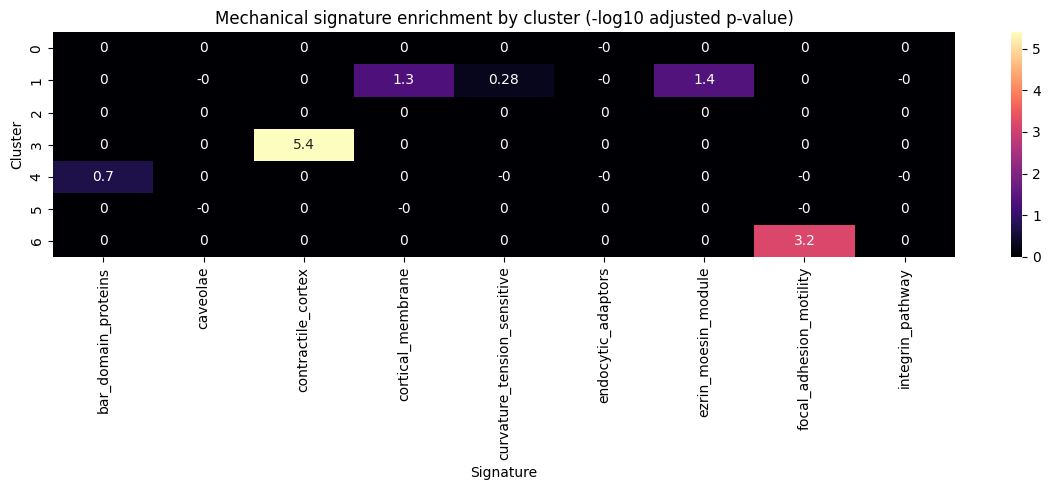

In [63]:
sig_plot_df = signature_enrichment_df.copy()
sig_plot_df["score"] = -np.log10(sig_plot_df["p_adj_bh"].clip(lower=1e-300))
sig_plot_df.loc[sig_plot_df["overlap_genes"] < 1, "score"] = 0.0

sig_heatmap = sig_plot_df.pivot(
    index="cluster",
    columns="signature",
    values="score"
).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(sig_heatmap, annot=True, cmap="magma")
plt.title("Mechanical signature enrichment by cluster (-log10 adjusted p-value)")
plt.xlabel("Signature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [64]:
for cl in sorted(signature_enrichment_df["cluster"].unique()):
    sub = signature_enrichment_df[signature_enrichment_df["cluster"] == cl].copy()
    sub = sub.sort_values(["p_adj_bh", "odds_ratio"], ascending=[True, False])

    print("=" * 100)
    print(f"CLUSTER {cl}")

    top = sub[(sub["overlap_genes"] >= 2)].head(5)

    if len(top) == 0:
        print("No strong targeted mechanical signatures detected.\n")
        continue

    for _, row in top.iterrows():
        print(
            f"- {row['signature']}: overlap={row['overlap_genes']}, "
            f"OR={row['odds_ratio']:.2f}, FDR={row['p_adj_bh']:.3g}"
        )
        print(f"  genes: {row['matched_genes']}")
    print()

CLUSTER 0
No strong targeted mechanical signatures detected.

CLUSTER 1
- ezrin_moesin_module: overlap=5, OR=inf, FDR=0.0424
  genes: EZR, MSN, RDX, SLC9A3R1, SLC9A3R2
- cortical_membrane: overlap=6, OR=14.84, FDR=0.0484
  genes: EPB41L2, EPB41L5, EZR, MSN, RDX, SCRIB
- curvature_tension_sensitive: overlap=5, OR=4.11, FDR=0.526
  genes: CAVIN1, CAVIN2, EZR, MSN, RDX
- caveolae: overlap=2, OR=4.91, FDR=1
  genes: CAVIN1, CAVIN2
- integrin_pathway: overlap=3, OR=3.69, FDR=1
  genes: ITGA3, ITGB1, ITGB4

CLUSTER 2
No strong targeted mechanical signatures detected.

CLUSTER 3
- contractile_cortex: overlap=5, OR=inf, FDR=4.08e-06
  genes: CALD1, FLNA, FLNB, MYH9, SEPTIN2

CLUSTER 4
- bar_domain_proteins: overlap=4, OR=inf, FDR=0.198
  genes: AMPH, PACSIN2, PACSIN3, SNX9
- focal_adhesion_motility: overlap=4, OR=1.82, FDR=1
  genes: BCAR1, LASP1, PTK2B, TLN1
- integrin_pathway: overlap=2, OR=1.21, FDR=1
  genes: BCAR1, TLN1
- curvature_tension_sensitive: overlap=3, OR=1.09, FDR=1
  genes: AMP

## Interpretation of the enrichment results

These analyses help distinguish two related but different claims:

1. **GO enrichment** shows that the clusters are biologically structured rather than arbitrary partitions.
2. **Mechanical signature enrichment** suggests that some clusters may correspond to distinct membrane mechanical regimes, including cortical organization, adhesion-dependent tension, contractility, and curvature-associated trafficking.

This is still an indirect interpretation, because static HPA embeddings do not directly measure membrane fluctuations or dynamic resonance.

In [44]:
import os

os.makedirs("results", exist_ok=True)

for cl in sorted(gene_df["gene_major_cluster"].unique()):
    genes_cl = gene_df.loc[
        gene_df["gene_major_cluster"] == cl, "genes"
    ].dropna().unique()

    pd.Series(sorted(genes_cl)).to_csv(
        f"results/cluster_{cl}_genes.txt",
        index=False,
        header=False
    )

print("Saved gene lists to results/")

Saved gene lists to results/


## 11. Technical bias checks

A key concern in image-based clustering is that the discovered structure may reflect technical artifacts rather than biology.

To address this, I examine two possible bias sources:
- **cell line bias**
- **antibody bias**

For each cluster, I compute entropy and the fraction of the most dominant cell line or antibody.

In [45]:
from scipy.stats import entropy

rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl]

    probs = sub["cell_line"].value_counts(normalize=True).values
    ent = entropy(probs)

    rows.append({
        "cluster": cl,
        "n_rows": len(sub),
        "cell_line_entropy": ent,
        "top_cell_line_frac": sub["cell_line"].value_counts(normalize=True).iloc[0]
    })

cell_bias_df = pd.DataFrame(rows)
cell_bias_df

,cluster,n_rows,cell_line_entropy,top_cell_line_frac
0,0,1338,2.668286,0.279522
1,1,3757,2.568343,0.307426
2,2,2231,2.455152,0.277454
3,3,535,2.169593,0.368224
4,4,4479,2.341387,0.333110
5,5,592,2.353981,0.255068
6,6,117,1.713516,0.444444


In [46]:
rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl]

    probs = sub["antibody"].value_counts(normalize=True).values
    ent = entropy(probs)

    rows.append({
        "cluster": cl,
        "antibody_entropy": ent,
        "top_antibody_frac": sub["antibody"].value_counts(normalize=True).iloc[0]
    })

ab_bias_df = pd.DataFrame(rows)
ab_bias_df

,cluster,antibody_entropy,top_antibody_frac
0,0,6.142831,0.004484
1,1,7.109462,0.001597
2,2,6.451206,0.002689
3,3,5.139454,0.011215
4,4,7.110713,0.001340
5,5,5.577921,0.010135
6,6,3.835740,0.051282


In [47]:
main_loc_ct = pd.crosstab(
    pm_df["cluster"],
    pm_df["main_location"]
)

main_loc_prop = main_loc_ct.div(main_loc_ct.sum(axis=1), axis=0)

top_cols = main_loc_ct.sum(axis=0).sort_values(ascending=False).head(20).index
main_loc_prop_top = main_loc_prop[top_cols]

main_loc_prop_top

main_location,Plasma membrane,Cytosol;Plasma membrane,Cytosol,Nucleoplasm,Nucleoplasm;Plasma membrane,Plasma membrane;Vesicles,Cytosol;Nucleoplasm,Cell Junctions;Plasma membrane,Vesicles,Cytosol;Nucleoplasm;Plasma membrane,Golgi apparatus;Plasma membrane,Golgi apparatus,Actin filaments;Plasma membrane,Actin filaments,Endoplasmic reticulum;Plasma membrane,Nuclear speckles,Mitochondria,Focal adhesion sites;Plasma membrane,Nucleoli,Cytosol;Vesicles
cluster,,,,,,,,,,,,,,,,,,,,
0,0.165172,0.036622,0.037369,0.026158,0.012706,0.051570,0.012706,0.006726,0.059791,0.000747,0.050822,0.067265,0.000000,0.001495,0.011958,0.018685,0.038864,0.001495,0.034380,0.008221
1,0.513175,0.130689,0.031940,0.033537,0.040458,0.031940,0.011179,0.028480,0.013042,0.013308,0.016503,0.007453,0.006122,0.004259,0.007453,0.005856,0.003194,0.006654,0.002662,0.001065
2,0.138951,0.073061,0.028687,0.284626,0.133124,0.029583,0.110264,0.009861,0.012999,0.047064,0.009861,0.003138,0.003138,0.000000,0.000000,0.009861,0.003138,0.000000,0.000000,0.001345
3,0.261682,0.078505,0.026168,0.020561,0.011215,0.020561,0.009346,0.011215,0.003738,0.005607,0.000000,0.000000,0.170093,0.140187,0.009346,0.000000,0.000000,0.003738,0.000000,0.000000
4,0.269033,0.290690,0.184193,0.008707,0.010270,0.030364,0.016968,0.006475,0.023443,0.015182,0.008038,0.002679,0.002009,0.001116,0.009154,0.002456,0.002902,0.001786,0.000893,0.007591
5,0.347973,0.035473,0.015203,0.040541,0.037162,0.021959,0.000000,0.282095,0.015203,0.000000,0.003378,0.005068,0.000000,0.006757,0.000000,0.010135,0.000000,0.011824,0.000000,0.003378
6,0.094017,0.051282,0.008547,0.042735,0.042735,0.034188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017094,0.017094,0.000000,0.000000,0.000000,0.170940,0.000000,0.000000


## 12. Visualization of localization patterns

To visualize how localization annotations differ across clusters, I compute cluster-wise proportions for:

- main location
- additional location
- combined location labels

These heatmaps help connect the unsupervised latent clusters to interpretable cellular localization patterns.

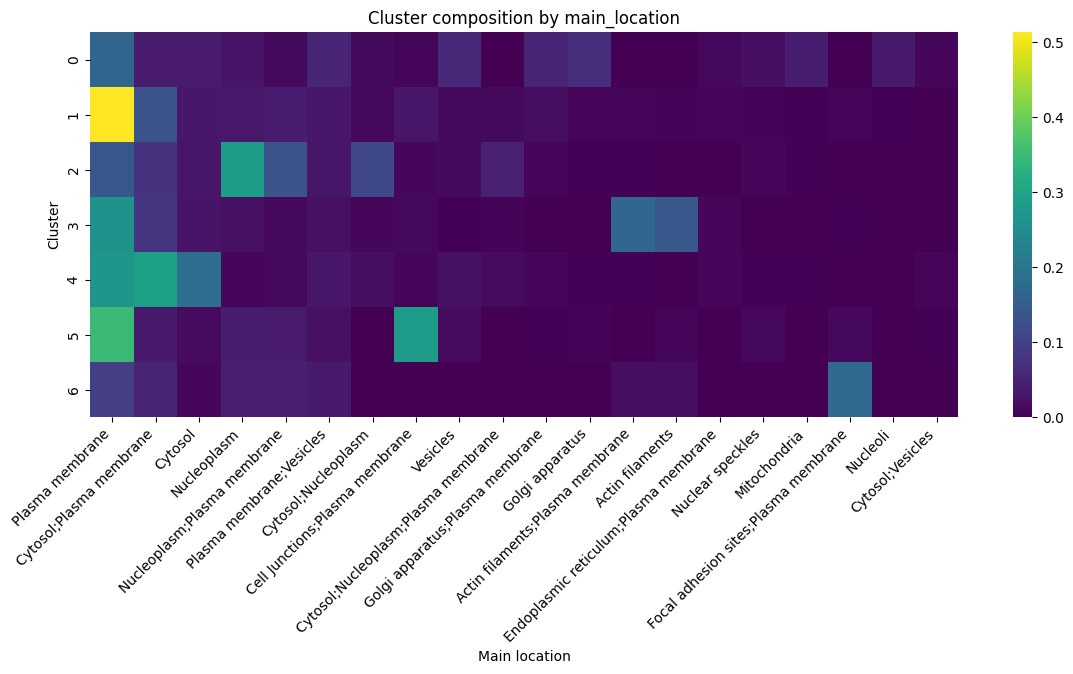

In [48]:

plt.figure(figsize=(14, 5))
sns.heatmap(main_loc_prop_top, cmap="viridis")
plt.title("Cluster composition by main_location")
plt.xlabel("Main location")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.show()

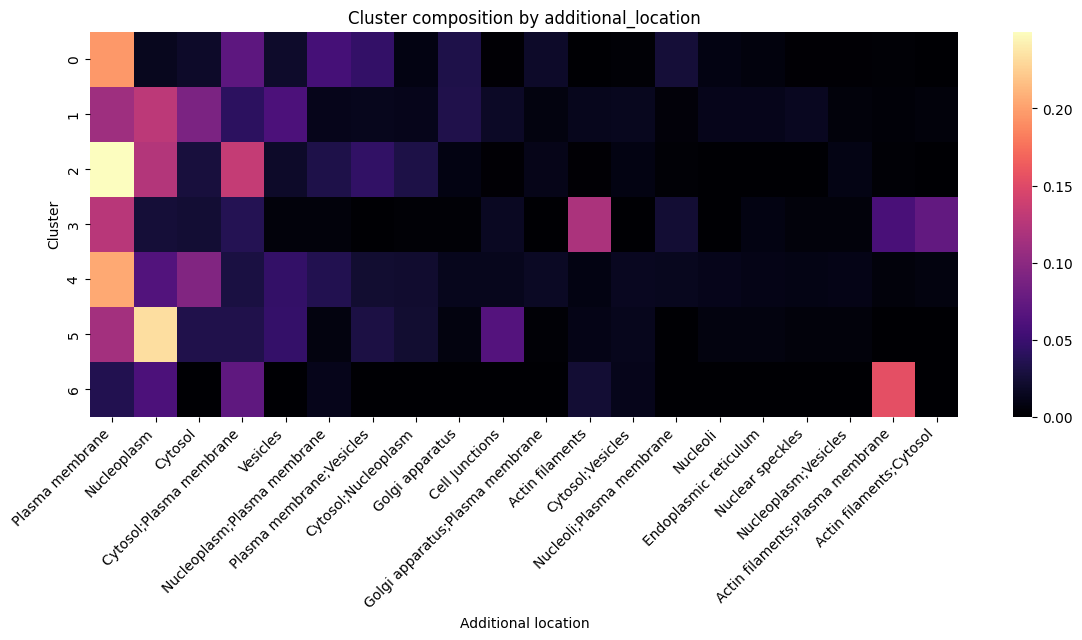

In [49]:
add_loc_ct = pd.crosstab(
    pm_df["cluster"],
    pm_df["additional_location"]
)

add_loc_prop = add_loc_ct.div(add_loc_ct.sum(axis=1), axis=0)

top_add_cols = add_loc_ct.sum(axis=0).sort_values(ascending=False).head(20).index
add_loc_prop_top = add_loc_prop[top_add_cols]

plt.figure(figsize=(14, 5))
sns.heatmap(add_loc_prop_top, cmap="magma")
plt.title("Cluster composition by additional_location")
plt.xlabel("Additional location")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.show()

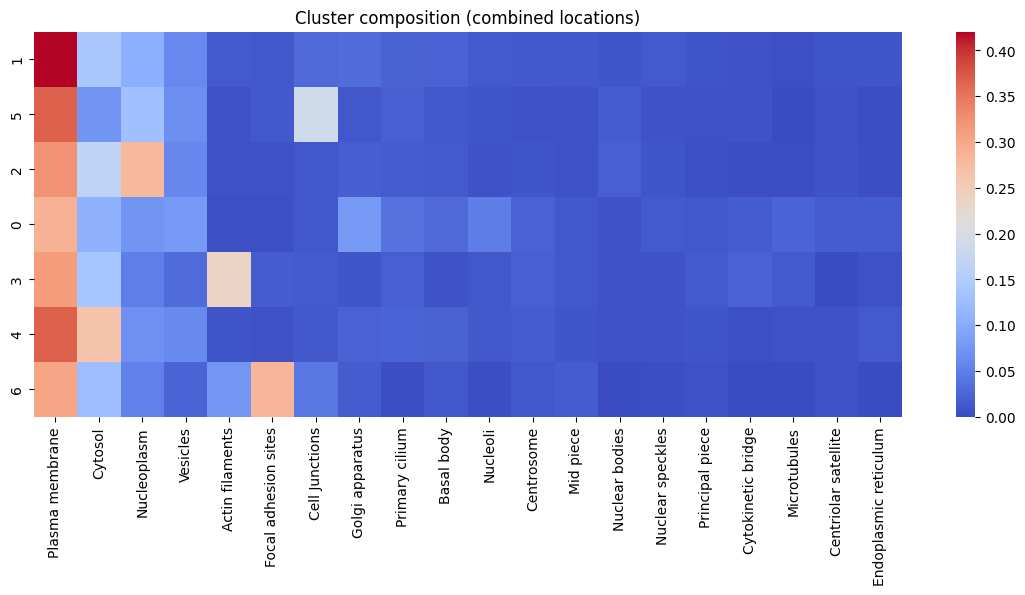

In [50]:
def split_locs(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(";") if i.strip()]

from collections import Counter, defaultdict

cluster_loc_counts = defaultdict(Counter)

for _, row in pm_df.iterrows():
    cl = row["cluster"]

    locs = []
    locs += split_locs(row["main_location"])
    locs += split_locs(row["additional_location"])

    locs = list(set(locs))

    for loc in locs:
        cluster_loc_counts[cl][loc] += 1

loc_df = pd.DataFrame(cluster_loc_counts).fillna(0).T
loc_df = loc_df.div(loc_df.sum(axis=1), axis=0)

top_locs = loc_df.sum(axis=0).sort_values(ascending=False).head(20).index
loc_df_top = loc_df[top_locs]

plt.figure(figsize=(14, 5))
sns.heatmap(loc_df_top, cmap="coolwarm")
plt.title("Cluster composition (combined locations)")
plt.show()

The following heatmaps provide a compact visual summary of localization enrichment patterns across clusters.

In [51]:
for cl in sorted(pm_df["cluster"].unique()):
    print("=" * 60)
    print("CLUSTER", cl)
    print(
        pm_df.loc[pm_df["cluster"] == cl, "genes"]
        .value_counts()
        .head(25)
    )

CLUSTER 0
genes
IRAK4       12
EGFR        11
CLTA         9
SIRT2        9
RRP12        9
BRAF         9
FADS2        8
GCC1         8
VWA5B1       8
ABCB6        8
AAMP         7
MAP7D3       7
KIAA1328     7
IDH3G        6
GPRC5A       6
LMTK2        6
CMTM4        6
NPR1         6
BSDC1        6
NALCN        6
C12orf73     6
SNX15        6
WDR11        6
SDHA         6
KNSTRN       6
Name: count, dtype: int64
CLUSTER 1
genes
MSN           28
EZR           20
CTNNB1        15
EGFR          14
SLC16A1       14
PALM2AKAP2    13
CD44          12
SAMSN1        12
SLC1A5        12
CAVIN1        12
BAIAP2L1      11
TNKS1BP1      11
PPP1R18       11
CSPG4         10
CTNND1        10
MYO1B         10
MARCKS        10
B2M            9
AKAP12         9
ANXA1          9
SCRIB          9
SDC2           9
VIL1           8
CCDC136        8
NCS1           8
Name: count, dtype: int64
CLUSTER 2
genes
ACSS2       13
CEBPE       12
POGZ        12
DLL3        12
KLHL7       12
DNAJC9      12
INTS12    

## 13. Marker Genes and Final Biological Naming

Finally, I inspect the most frequent genes in each cluster and assign an interpretable biological label to each state.

These labels are not treated as absolute ground truth. They are working biological interpretations based on marker composition, localization enrichment, and known protein functions.

The final cluster names summarize the dominant biological theme of each latent state:

- receptor/endocytic membrane
- cortical surface membrane
- endomembrane-associated membrane
- contractile cortex membrane
- signaling/remodeling membrane
- junctional/polarity membrane
- focal adhesion/motility membrane

In [52]:
cluster_labels = {
    0: "receptor_endocytic_pm",
    1: "cortical_surface_pm",
    2: "endomembrane_associated_pm",
    3: "contractile_cortex_pm",
    4: "signaling_remodeling_pm",
    5: "junctional_polarity_pm",
    6: "focal_adhesion_motility_pm"
}

pm_df["cluster_name"] = pm_df["cluster"].map(cluster_labels)
pm_df[["cluster", "cluster_name"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_name
179,0,receptor_endocytic_pm
0,1,cortical_surface_pm
80,2,endomembrane_associated_pm
226,3,contractile_cortex_pm
256,4,signaling_remodeling_pm
32,5,junctional_polarity_pm
562,6,focal_adhesion_motility_pm


## 14. Conclusions

This analysis suggests that plasma membrane-associated proteins are not a single homogeneous category in Human Protein Atlas image embedding space.

Instead, they separate into multiple reproducible latent states that are biologically interpretable and linked to distinct cellular programs, including:

- receptor trafficking and endocytosis
- cortical membrane organization
- cell-cell junctions and polarity
- focal adhesion and motility
- contractile cortex dynamics
- signaling and remodeling
- mixed endomembrane-associated states

Overall, the results support the central hypothesis of the project:  
**plasma membrane proteins split into multiple reproducible localization states rather than forming one uniform class.**